In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
plt.style.use('seaborn')
sns.set(font_scale=2)
import missingno as msno

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.set_random_seed(777)
import datetime
from sklearn.preprocessing import MinMaxScaler

In [2]:
def data_standardization(x):
    x_np = np.asarray(x)
    return (x_np - x_np.mean()) / x_np.std()

def min_max_scaling(x):
    x_np = np.asarray(x)
    return (x_np - x_np.min()) / (x_np.max() - x_np.min() + 1e-7)

def reverse_min_max_scaling(org_x, x):
    org_x_np = np.asarray(org_x)
    x_np = np.asarray(x)
    return (x_np * (org_x_np.max() - org_x_np.min() + 1e-7)) + org_x_np.min()

In [3]:
df_train = pd.read_csv('./data/train.csv')
# df_test = pd.read_csv('./data/test.csv')

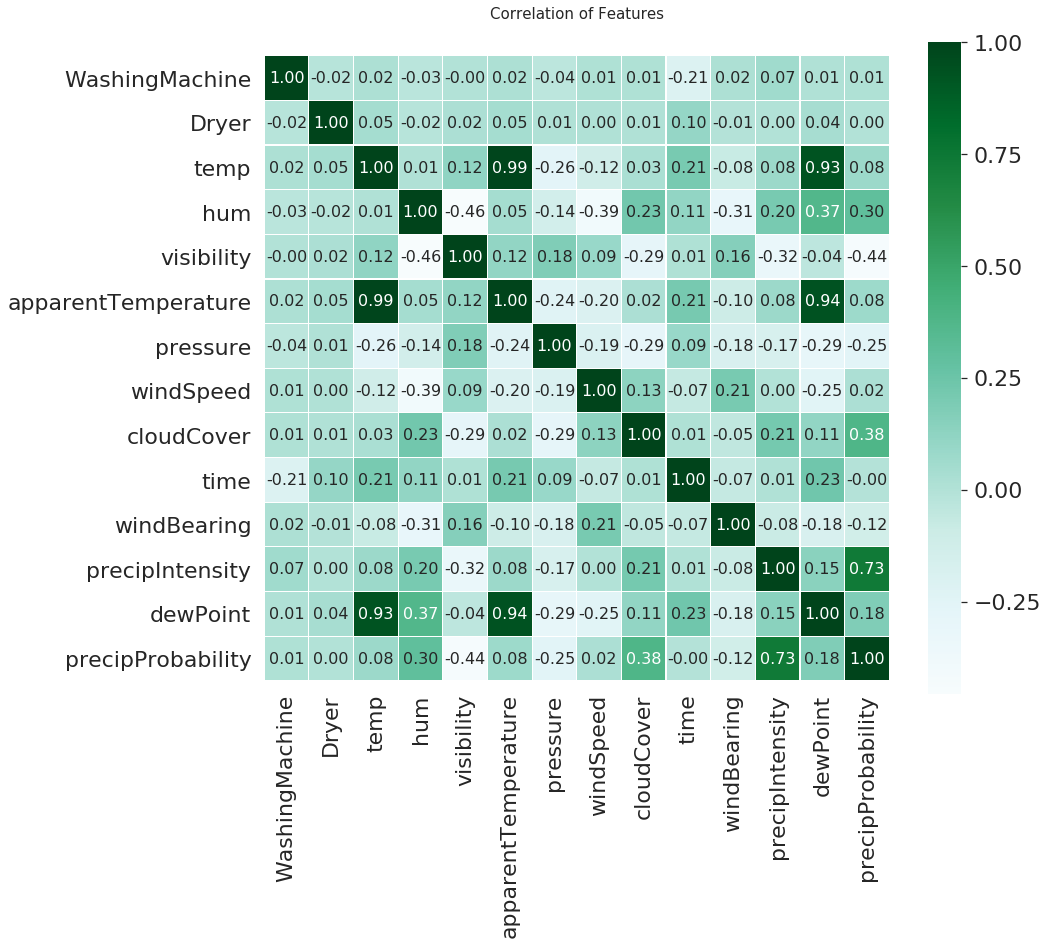

In [4]:
heatmap_data = df_train[['WashingMachine', 'Dryer', 'temp', 'hum', 'visibility', 'apparentTemperature', 'pressure', 'windSpeed', 'cloudCover', 'time', 'windBearing', 'precipIntensity', 'dewPoint', 'precipProbability']]
colormap = plt.cm.BuGn
plt.figure(figsize=(14, 12))
plt.title('Correlation of Features', y=1.05, size=15)
sns.heatmap(heatmap_data.astype(float).corr(), linewidths=0.1, vmax=1.0, square=True, cmap=colormap, linecolor='white', annot=True, annot_kws={'size':16}, fmt='.2f')

In [5]:
df_train.describe()

,WashingMachine,Dryer,temp,hum,visibility,apparentTemperature,pressure,windSpeed,cloudCover,time,windBearing,precipIntensity,dewPoint,precipProbability,dayOfWeeks
count,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17519.000000,17515.000000,15182.000000,1.752000e+04,17510.000000,17520.000000,17520.000000,17520.000000,17520.000000
mean,0.005305,0.015370,46.982498,0.692937,9.064854,44.011365,1017.010068,6.298197,0.197393,1.420085e+09,203.012050,0.003139,36.507075,0.059954,3.001370
std,0.022422,0.126911,20.565457,0.181778,1.920542,23.928811,7.872054,3.675946,0.264075,1.820739e+07,91.306484,0.014769,20.868612,0.172391,1.997658
min,0.000000,0.000000,-13.720000,0.100000,0.330000,-29.370000,982.550000,0.000000,0.000000,1.388552e+09,0.000000,0.000000,-20.950000,0.000000,0.000000
25%,0.000087,0.002586,32.147500,0.550000,9.310000,26.570000,1011.915000,3.580000,0.020000,1.404316e+09,127.000000,0.000000,22.487500,0.000000,1.000000
50%,0.001602,0.003837,48.565000,0.720000,10.000000,46.325000,1016.890000,5.630000,0.080000,1.420087e+09,210.000000,0.000000,38.240000,0.000000,3.000000
75%,0.005599,0.006010,63.530000,0.850000,10.000000,63.530000,1021.870000,8.360000,0.280000,1.435850e+09,279.000000,0.000000,54.690000,0.000000,5.000000
max,1.074639,2.824717,90.260000,0.980000,10.000000,95.350000,1043.560000,24.470000,1.000000,1.451621e+09,359.000000,0.409200,74.010000,0.880000,6.000000


In [6]:
# 각 컬럼의 null이 차지하는 퍼센트 확인
for col in df_train.columns:
    msg = 'column: {:>10}\t Percent of NaN value: {:.2f}%'.format(col, 100 * (df_train[col].isnull().sum() / df_train[col].shape[0]))
    print(msg)

column:  date&time	 Percent of NaN value: 0.00%
column: WashingMachine	 Percent of NaN value: 0.00%
column:      Dryer	 Percent of NaN value: 0.00%
column:       temp	 Percent of NaN value: 0.00%
column:       icon	 Percent of NaN value: 0.00%
column:        hum	 Percent of NaN value: 0.00%
column: visibility	 Percent of NaN value: 0.00%
column:    summary	 Percent of NaN value: 0.00%
column: apparentTemperature	 Percent of NaN value: 0.00%
column:   pressure	 Percent of NaN value: 0.01%
column:  windSpeed	 Percent of NaN value: 0.03%
column: cloudCover	 Percent of NaN value: 13.34%
column:       time	 Percent of NaN value: 0.00%
column: windBearing	 Percent of NaN value: 0.06%
column: precipIntensity	 Percent of NaN value: 0.00%
column:   dewPoint	 Percent of NaN value: 0.00%
column: precipProbability	 Percent of NaN value: 0.00%
column: dayOfWeeks	 Percent of NaN value: 0.00%


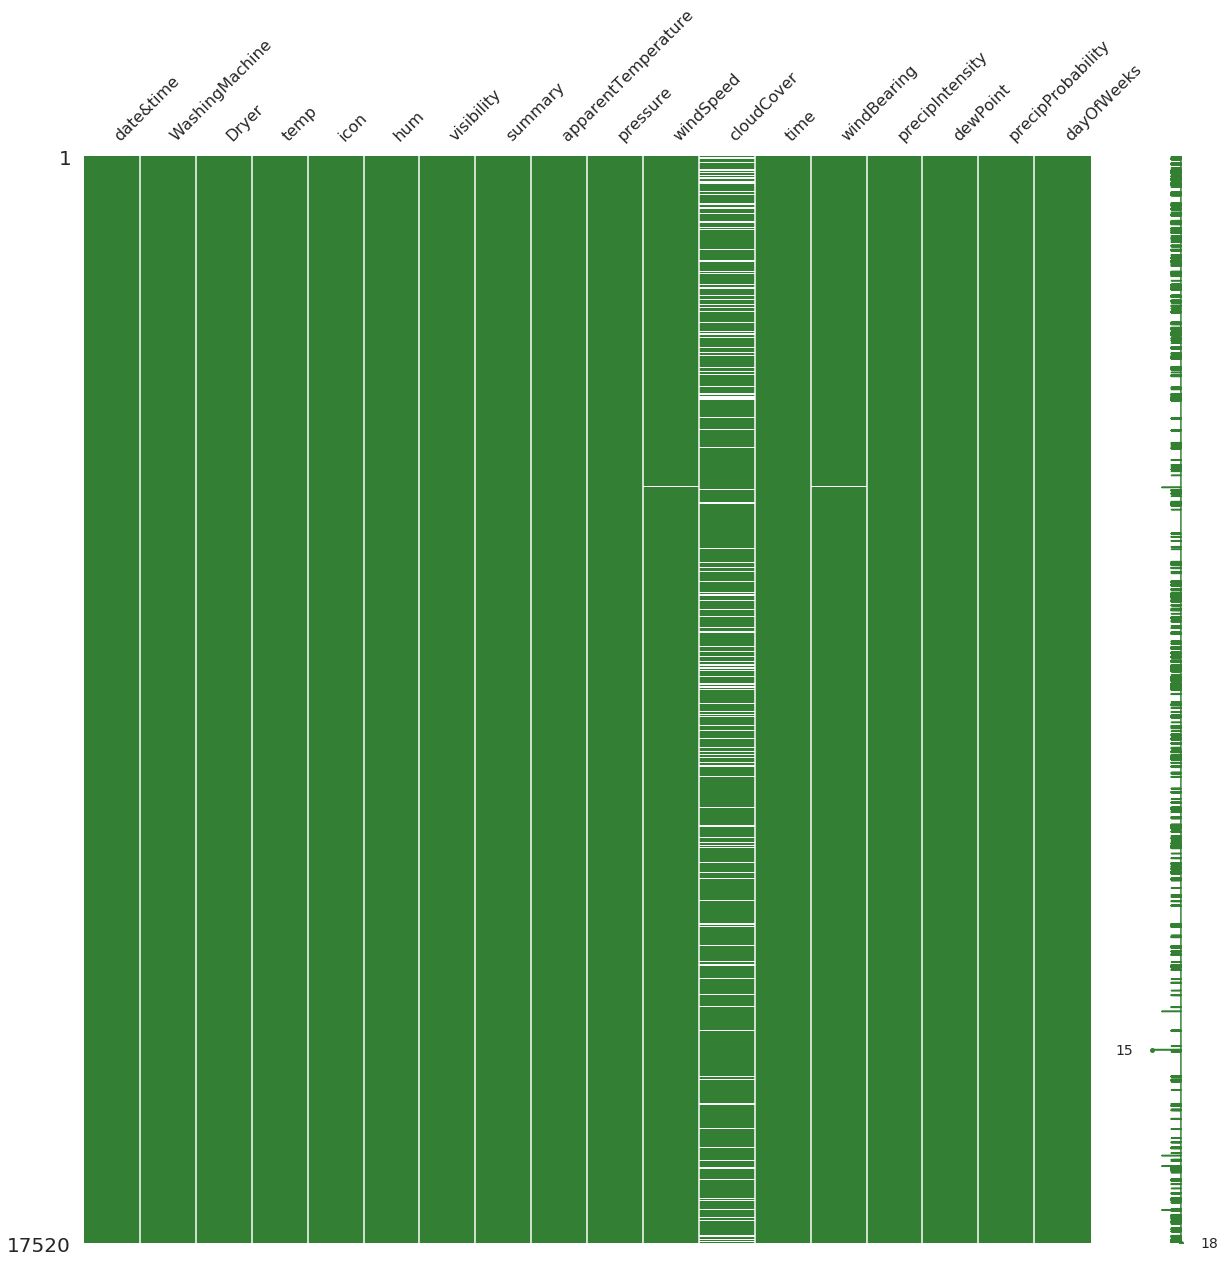

In [7]:
msno.matrix(df=df_train.iloc[:, :], figsize=(20, 20), color=(0.2, 0.5, 0.2))

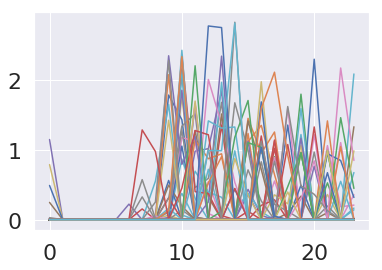

In [8]:
for i in range(int(len(df_train) / 24)):
    plt.plot([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23],df_train['Dryer'][i*24:i*24+24])

In [9]:
df_train.groupby(['icon']).count()

,date&time,WashingMachine,Dryer,temp,hum,visibility,summary,apparentTemperature,pressure,windSpeed,cloudCover,time,windBearing,precipIntensity,dewPoint,precipProbability,dayOfWeeks
icon,,,,,,,,,,,,,,,,,
clear-day,5561,5561,5561,5561,5561,5561,5561,5561,5560,5559,4861,5561,5556,5561,5561,5561,5561
clear-night,6067,6067,6067,6067,6067,6067,6067,6067,6067,6064,5390,6067,6063,6067,6067,6067,6067
cloudy,516,516,516,516,516,516,516,516,516,516,516,516,516,516,516,516,516
fog,78,78,78,78,78,78,78,78,78,78,67,78,78,78,78,78,78
partly-cloudy-day,1921,1921,1921,1921,1921,1921,1921,1921,1921,1921,1921,1921,1920,1921,1921,1921,1921
partly-cloudy-night,1316,1316,1316,1316,1316,1316,1316,1316,1316,1316,1316,1316,1316,1316,1316,1316,1316
rain,1592,1592,1592,1592,1592,1592,1592,1592,1592,1592,911,1592,1592,1592,1592,1592,1592
snow,426,426,426,426,426,426,426,426,426,426,159,426,426,426,426,426,426
wind,43,43,43,43,43,43,43,43,43,43,41,43,43,43,43,43,43


In [10]:
train_data = [df_train]

icon_mapping = {'clear-day':0, 'clear-night':1, 'cloudy':2, 'fog':3, 'partly-cloudy-day':4, 'partly-cloudy-night':5, 'rain':6, 'snow':7, 'wind':8}
for dataset in train_data:
    dataset['icon'] = dataset['icon'].map(icon_mapping)

In [11]:
# df_train.drop(['summary'], axis=1, inplace=True)

In [12]:
# df_train.drop(['precipIntensity'],axis=1,inplace=True)

In [13]:
# df_train.head()

In [14]:
# df_train.groupby('visibility').count()

In [15]:
# test_X = df_test.drop(['date&time', 'WashingMachine', 'Dryer'], axis=1).values
# test_Y = df_test['Dryer'].values

In [16]:
# train_X = df_train.drop(['date&time', 'WashingMachine', 'Dryer'], axis=1).values
# train_Y = df_train['Dryer'].values

In [17]:
# fig, ax = plt.subplots(1, 1, figsize=(8, 8))
# g = sns.distplot(df_train['visibility'], color='b', label='Skewness:{:.2f}'.format(df_train['visibility'].skew()), ax=ax)
# g = g.legend(loc='best')

In [18]:
# df_test.drop(['date&time', 'visibility', 'summary', 'time', 'precipIntensity', 'precipProbability'], axis=1, inplace=True)
# df_train.drop(['visibility', 'precipProbability'], axis=1, inplace=True)

In [19]:
# df_train = pd.get_dummies(df_train, columns=['icon'], prefix='icon')
# df_test = pd.get_dummies(df_test, columns=['icon'], prefix='icon')

In [20]:
df_train.count()

date&time              17520
WashingMachine         17520
Dryer                  17520
temp                   17520
icon                   17520
hum                    17520
visibility             17520
summary                17520
apparentTemperature    17520
pressure               17519
windSpeed              17515
cloudCover             15182
time                   17520
windBearing            17510
precipIntensity        17520
dewPoint               17520
precipProbability      17520
dayOfWeeks             17520
dtype: int64

In [21]:
# train_X = df_train.drop(['WashingMachine', 'Dryer'], axis=1)
# train_Y = df_train['Dryer']
# test_X = df_test.drop(['WashingMachine', 'Dryer'], axis=1)
# test_Y = df_test['Dryer']

In [22]:
# test_Y

In [23]:
# seq_length = 24
# data_dim = 17
# hidden_dim = 10
# output_dim = 1
# learning_rate = 0.001
# iterations = 1000

# train_x = []
# train_y = []

# for i in range(len(train_X) - seq_length):
#     _x = train_X[i:i+seq_length]
#     _y = train_Y[i+seq_length]
#     train_x.append(_x)
#     train_y.append(_y)

# test_x = []
# test_y = []

# for i in range(len(test_X) - seq_length):
#     _x = test_X[i:i+seq_length]
#     _y = test_Y[i+seq_length]
#     test_x.append(_x)
#     test_y.append(_y)

In [24]:
# train_x = np.array(train_x)
# train_y = np.array(train_y)
# test_x = np.array(test_x)
# test_y = np.array(test_y)

In [25]:
# real_train_y = []
# for i in range(len(train_y)):
#     temp = []
#     temp.append(train_y[i])
#     real_train_y.append(temp)
# print(np.shape(real_train_y))
# train_y = real_train_y

# real_test_y = []
# for i in range(len(test_y)):
#     temp = []
#     temp.append(test_y[i])
#     real_test_y.append(temp)
# print(np.shape(real_test_y))
# test_y = real_test_y

In [26]:
# X = tf.placeholder(tf.float32, [None, seq_length, data_dim])
# Y = tf.placeholder(tf.float32, [None, output_dim])

# W = tf.Variable(tf.random_normal([hidden_dim, output_dim]))
# b = tf.Variable(tf.random_normal([output_dim]))

# cell = tf.nn.rnn_cell.BasicRNNCell(hidden_dim)
# outputs, states = tf.nn.dynamic_rnn(cell, X, dtype=tf.float32)

# outputs = tf.transpose(outputs, [1, 0, 2])
# outputs = outputs[-1]
# model = tf.matmul(outputs, W) + b

# cost = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits_v2(logits=model, labels=Y))
# optimizer = tf.train.AdamOptimizer(learning_rate).minimize(cost)

# sess = tf.Session()
# sess.run(tf.global_variables_initializer())

# for i in range(iterations):
#     _, step_cost = sess.run([optimizer, cost], feed_dict={X:train_x, Y:train_y})
#     print("step: {}, cost: {}".format(i, step_cost))

# is_correct = tf.equal(tf.argmax(model, 1), tf.argmax(Y, 1))
# accuracy = tf.reduce_mean(tf.cast(is_correct, tf.float32))

# print('학습 정확도:', sess.run(accuracy, feed_dict={X:train_x, Y:train_y}))
# print('테스트 정확도:', sess.run(accuracy, feed_dict={X:test_x, Y:test_y}))

In [27]:
# import numpy as np
# from keras.models import Sequential
# from keras.layers import Dense, LSTM, Dropout
# from sklearn.preprocessing import MinMaxScaler
# import matplotlib.pyplot as plt
# %matplotlib inline

# look_back = 24

# train_x = np.reshape(train_x, (train_x.shape[0], train_x.shape[1], 17))
# test_x = np.reshape(test_x, (test_x.shape[0], test_x.shape[1], 17))
# model = Sequential()
# for i in range(2):
#     model.add(LSTM(32, batch_input_shape=(1, 24, 17), stateful=True, return_sequences=True))
#     model.add(Dropout(0.3))
# model.add(LSTM(32, batch_input_shape=(1, 24, 17), stateful=True))
# model.add(Dropout(0.3))
# model.add(Dense(1))

# model.compile(loss='mean_squared_error', optimizer='adam')

# class CustomHistory(keras.callbacks.Callback):
#     def init(self):
#         self.train_loss = []
#         self.val_loss = []
        
#     def on_epoch_end(self, batch, logs={}):
#         self.train_loss.append(logs.get('loss'))
#         self.val_loss.append(logs.get('val_loss'))

# custom_hist = CustomHistory()
# custom_hist.init()

# for i in range(200):
#     model.fit(np.array(train_x), np.array(train_y), epochs=1, batch_size=1, shuffle=False, callbacks=[custom_hist], validation_data=(np.array(test_x), np.array(test_y)))
#     model.reset_states()

In [28]:
input_data_column_cnt = 4
output_data_column_cnt = 1

seq_length = 24
rnn_cell_hidden_dim = 20
forget_bias = 1.0
num_stacked_layers = 1
keep_prob = 1.0

epoch_num = 100
learning_rate = 0.01

In [29]:
train_data = [df_train]

for dataset in train_data:
    dataset['time'] = dataset['date&time'].str.extract('(\d*[:]\d*)', expand=False)
    
df_train.head()

,date&time,WashingMachine,Dryer,temp,icon,hum,visibility,summary,apparentTemperature,pressure,windSpeed,cloudCover,time,windBearing,precipIntensity,dewPoint,precipProbability,dayOfWeeks
0,2014-01-01 0:00,0.005686,0.005231,16.67,1,0.53,10.0,Clear,3.95,1022.69,11.23,0.00,0:00,271.0,0.0,2.41,0.0,3
1,2014-01-01 1:00,0.005635,0.005293,16.19,1,0.52,10.0,Clear,4.18,1022.58,9.92,0.02,1:00,268.0,0.0,1.68,0.0,3
2,2014-01-01 2:00,0.005570,0.005368,15.69,1,0.55,10.0,Clear,4.41,1023.61,8.72,0.00,2:00,266.0,0.0,2.59,0.0,3
3,2014-01-01 3:00,0.005543,0.005527,15.29,1,0.58,10.0,Clear,4.29,1024.31,8.25,0.00,3:00,269.0,0.0,3.29,0.0,3
4,2014-01-01 4:00,0.005597,0.005630,15.37,1,0.60,10.0,Clear,5.12,1024.51,7.38,0.06,4:00,266.0,0.0,3.95,0.0,3


In [30]:
df_train.drop(['date&time', 'visibility', 'summary', 'precipIntensity', 'precipProbability'], axis=1, inplace=True)

In [31]:
df_train.head()

,WashingMachine,Dryer,temp,icon,hum,apparentTemperature,pressure,windSpeed,cloudCover,time,windBearing,dewPoint,dayOfWeeks
0,0.005686,0.005231,16.67,1,0.53,3.95,1022.69,11.23,0.00,0:00,271.0,2.41,3
1,0.005635,0.005293,16.19,1,0.52,4.18,1022.58,9.92,0.02,1:00,268.0,1.68,3
2,0.005570,0.005368,15.69,1,0.55,4.41,1023.61,8.72,0.00,2:00,266.0,2.59,3
3,0.005543,0.005527,15.29,1,0.58,4.29,1024.31,8.25,0.00,3:00,269.0,3.29,3
4,0.005597,0.005630,15.37,1,0.60,5.12,1024.51,7.38,0.06,4:00,266.0,3.95,3


In [32]:
time_mapping = {"0:00":0, "1:00":1, "2:00":2, "3:00":3, "4:00":4, "5:00":5, "6:00":6, "7:00":7, "8:00":8, "9:00":9, "10:00":10,
               "11:00":11, "12:00":12, "13:00":13, "14:00":14, "15:00":15, "16:00":16, "17:00":17, "18:00":18, "19:00":19, "20:00":20, "21:00":21, 
               "22:00":22, "23:00":23}
for dataset in train_data:
    dataset['time'] = dataset['time'].map(time_mapping)

In [33]:
df_all_np = df_train.values.astype(np.float)
scaler = MinMaxScaler()

device = df_all_np[:, 1:2]

temp = df_all_np[:, 2:3]
norm_temp = scaler.fit_transform(temp)

hum = df_all_np[:, 4:5]
norm_hum = scaler.fit_transform(hum)

time = df_all_np[:, 9:10]
norm_time = scaler.fit_transform(time)

x = np.concatenate((norm_time, norm_temp, norm_hum, device), axis=1)
print('x.shape ', x.shape)
print('x[0] ', x[0])
print('x[-1]', x[-1])

y = x[:, [3]]
print("y[0] ", y[0])

x.shape  (17520, 4)
x[0]  [0.         0.29226774 0.48863636 0.00523111]
x[-1] [1.         0.46970571 0.625      0.00315   ]
y[0]  [0.00523111]


In [34]:
dataX = []
dataY = []

for i in range(0, len(y) - seq_length):
    _x = x[i:i+seq_length]
    _y = y[i+seq_length]
    if i is 0:
        print(_x, '->', _y)
    dataX.append(_x)
    dataY.append(_y)

[[0.         0.29226774 0.48863636 0.00523111]
 [0.04347826 0.28765147 0.47727273 0.00529333]
 [0.08695652 0.28284285 0.51136364 0.00536778]
 [0.13043478 0.27899596 0.54545455 0.00552722]
 [0.17391304 0.27976534 0.56818182 0.00563   ]
 [0.2173913  0.27437969 0.625      0.00578833]
 [0.26086957 0.27043662 0.63636364 0.00581722]
 [0.30434783 0.26457011 0.64772727 0.00572667]
 [0.34782609 0.27139835 0.67045455 0.00602167]
 [0.39130435 0.29592229 0.68181818 0.00580167]
 [0.43478261 0.30784766 0.625      0.00622833]
 [0.47826087 0.32121562 0.53409091 0.00856167]
 [0.52173913 0.33217927 0.5        0.005875  ]
 [0.56521739 0.33977688 0.47727273 0.00597389]
 [0.60869565 0.33996922 0.46590909 0.00596056]
 [0.65217391 0.34102712 0.47727273 0.00631222]
 [0.69565217 0.33891133 0.48863636 0.00633   ]
 [0.73913043 0.32169648 0.53409091 0.00618833]
 [0.7826087  0.29794191 0.63636364 0.00667556]
 [0.82608696 0.29063281 0.67045455 0.00738444]
 [0.86956522 0.29919215 0.65909091 0.00658056]
 [0.91304348 

In [35]:
train_size = int(len(dataY) * 0.7)
test_size = len(dataY) - train_size

trainX = np.array(dataX[0:train_size])
trainY = np.array(dataY[0:train_size])

testX = np.array(dataX[train_size:len(dataX)])
testY = np.array(dataY[train_size:len(dataY)])

In [36]:
X = tf.placeholder(tf.float32, [None, seq_length, input_data_column_cnt], name='X')
print(X)
Y = tf.placeholder(tf.float32, [None, 1], name='Y')
print(Y)

targets = tf.placeholder(tf.float32, [None, 1], name='train_Y')
print(targets)

predictions = tf.placeholder(tf.float32, [None, 1], name='predicted_Y')
print(predictions)

Tensor("X:0", shape=(?, 24, 4), dtype=float32)
Tensor("Y:0", shape=(?, 1), dtype=float32)
Tensor("train_Y:0", shape=(?, 1), dtype=float32)
Tensor("predicted_Y:0", shape=(?, 1), dtype=float32)


In [37]:
def lstm_cell():
    cell = tf.contrib.rnn.BasicLSTMCell(num_units=rnn_cell_hidden_dim, forget_bias=forget_bias, state_is_tuple=True, activation=tf.nn.softsign)
    if keep_prob < 1.0:
        cell = tf.contrib.rnn.DropoutWrapper(cell, output_keep_prob=keep_prob)
    return cell

stackedRNNs = [lstm_cell() for _ in range(num_stacked_layers)]
multi_cells = tf.contrib.rnn.MultiRNNCell(stackedRNNs, state_is_tuple=True) if num_stacked_layers > 1 else lstm_cell()
print(multi_cells)

hypothesis, _states = tf.nn.dynamic_rnn(multi_cells, X, dtype=tf.float32)
print("hypothesis: ", hypothesis)

hypothesis = tf.contrib.layers.fully_connected(hypothesis[:, -1], output_data_column_cnt, activation_fn=tf.identity)

Instructions for updating:
Use the retry module or similar alternatives.
hypothesis:  Tensor("rnn/transpose_1:0", shape=(?, 24, 20), dtype=float32)


In [38]:
loss = tf.reduce_sum(tf.square(hypothesis - Y))
optimizer = tf.train.AdamOptimizer(learning_rate)

train = optimizer.minimize(loss)
rmse = tf.sqrt(tf.reduce_mean(tf.squared_difference(targets, predictions)))

In [39]:
train_error_summary = []
test_error_summary = []
test_predict = ''
predict_array = []

sess = tf.Session()
sess.run(tf.global_variables_initializer())

start_time = datetime.datetime.now()
print('학습 시작')
for epoch in range(epoch_num):
    _, _loss = sess.run([train, loss], feed_dict={X:trainX, Y:trainY})
    
    train_predict = sess.run(hypothesis, feed_dict = {X:trainX})
    train_error = sess.run(rmse, feed_dict = {targets:trainY, predictions:train_predict})
    train_error_summary.append(train_error)

    test_predict = sess.run(hypothesis, feed_dict={X:testX})
    test_error = sess.run(rmse, feed_dict={targets:testY, predictions:test_predict})
    test_error_summary.append(test_error)
        
    if((epoch+1) % 10 == 0) or (epoch == epoch_num - 1):    
        print("epoch: {}, train_error(A): {}, test_error(B): {}, B-A: {}".format(epoch+1, train_error, test_error, test_error-train_error))
        
end_time = datetime.datetime.now()
elapsed_time = end_time - start_time
print('elapsed_time:', elapsed_time)
print('elapsed_time per epoch:', elapsed_time/epoch_num)
predict_array.append(test_predict)

학습 시작
epoch: 10, train_error(A): 0.041212525218725204, test_error(B): 0.22923563420772552, B-A: 0.18802310526371002
epoch: 20, train_error(A): 0.008717965334653854, test_error(B): 0.23158302903175354, B-A: 0.2228650599718094
epoch: 30, train_error(A): 0.014884731732308865, test_error(B): 0.2344275712966919, B-A: 0.21954284608364105
epoch: 40, train_error(A): 0.007432661484926939, test_error(B): 0.23146799206733704, B-A: 0.2240353375673294
epoch: 50, train_error(A): 0.00845735240727663, test_error(B): 0.23079994320869446, B-A: 0.2223425954580307
epoch: 60, train_error(A): 0.0070136659778654575, test_error(B): 0.23122340440750122, B-A: 0.2242097407579422
epoch: 70, train_error(A): 0.007145362440496683, test_error(B): 0.23123276233673096, B-A: 0.2240874022245407
epoch: 80, train_error(A): 0.007018813397735357, test_error(B): 0.23089128732681274, B-A: 0.22387246787548065
epoch: 90, train_error(A): 0.006949542555958033, test_error(B): 0.23055605590343475, B-A: 0.22360651195049286
epoch: 100

In [40]:
def error_graph(i, train, test):
    plt.figure()
    plt.plot(train[i*100:(i+1)*100], 'r')
    plt.plot(test[i*100:(i+1)*100], 'b')

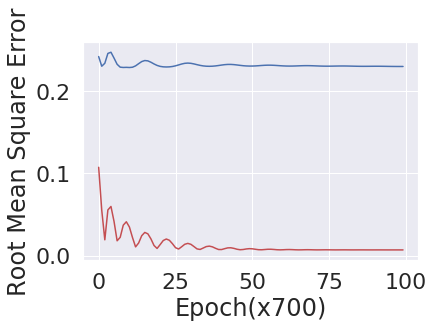

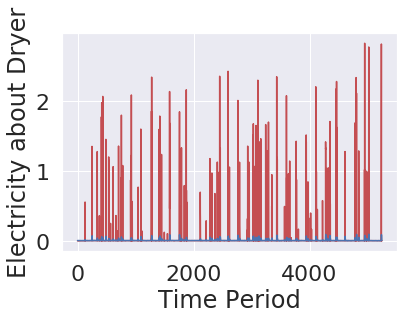

In [41]:
plt.figure(1)
plt.plot(train_error_summary, 'r')
plt.plot(test_error_summary, 'b')
plt.xlabel('Epoch(x700)')
plt.ylabel('Root Mean Square Error')

plt.figure(2)
plt.plot(testY, 'r')
plt.plot(test_predict, 'b')
plt.xlabel('Time Period')
plt.ylabel('Electricity about Dryer')
plt.show()

In [42]:
recent_data = np.array([x[len(x)-seq_length:]])
test_predict = sess.run(hypothesis, feed_dict={X:recent_data})

print("test_predict : ", test_predict[0])
test_predict = scaler.inverse_transform(test_predict)
print("reverse scaling : ")

test_predict :  [0.00557369]
reverse scaling : 


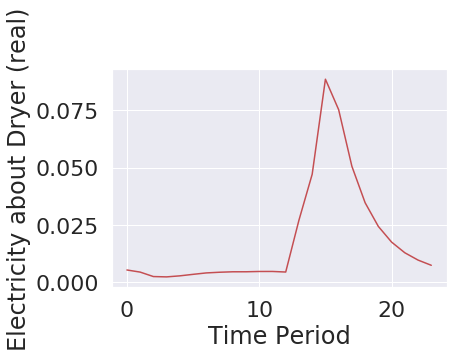

In [43]:
plt.figure()
plt.plot(predict_array[0][-24:], 'r')
# plt.plot(testY[-1], 'g')
plt.xlabel('Time Period')
plt.ylabel('Electricity about Dryer (real)')
plt.show()

In [57]:
time_electric_test = []
time_1 = 0
time_2 = 0
time_3 = 0
time_4 = 0
time_5 = 0
time_6 = 0
time_7 = 0
time_8 = 0
time_9 = 0
time_10 = 0
time_11 = 0
time_12 = 0
time_13 = 0
time_14 = 0
time_15 = 0
time_16 = 0
time_17 = 0
time_18 = 0
time_19 = 0
time_20 = 0
time_21 = 0
time_22 = 0
time_23 = 0
time_24 = 0
for i in range(len(testY)):
    if(i%24 == 0):
        time_1 += testY[i]
    elif(i%24 == 1):
        time_2 += testY[i]
    elif(i%24 == 2):
        time_3 += testY[i]
    elif(i%24 == 3):
        time_4 += testY[i]
    elif(i%24 == 4):
        time_5 += testY[i]
    elif(i%24 == 5):
        time_6 += testY[i]
    elif(i%24 == 6):
        time_7 += testY[i]
    elif(i%24 == 7):
        time_8 += testY[i]
    elif(i%24 == 8):
        time_9 += testY[i]
    elif(i%24 == 9):
        time_10 += testY[i]
    elif(i%24 == 10):
        time_11 += testY[i]
    elif(i%24 == 11):
        time_12 += testY[i]
    elif(i%24 == 12):
        time_13 += testY[i]
    elif(i%24 == 13):
        time_14 += testY[i]
    elif(i%24 == 14):
        time_15 += testY[i]
    elif(i%24 == 15):
        time_16 += testY[i]
    elif(i%24 == 16):
        time_17 += testY[i]
    elif(i%24 == 17):
        time_18 += testY[i]
    elif(i%24 == 18):
        time_19 += testY[i]
    elif(i%24 == 19):
        time_20 += testY[i]
    elif(i%24 == 20):
        time_21 += testY[i]
    elif(i%24 == 21):
        time_22 += testY[i]
    elif(i%24 == 22):
        time_23 += testY[i]
    elif(i%24 == 23):
        time_24 += testY[i]
        
time_electric_test = [time_1, time_2, time_3, time_4, time_5, time_6, time_7, time_8, time_9, time_10, time_11, time_12, time_13, time_14, time_15, time_16, time_17, time_18, time_19, time_20, time_21, time_22, time_23, time_24]

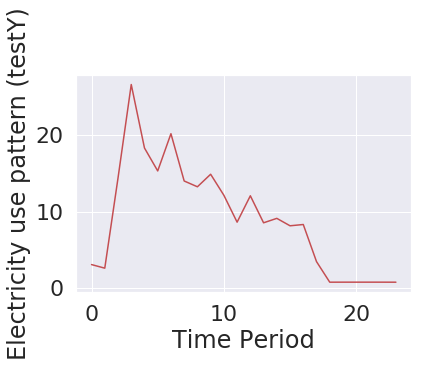

In [58]:
plt.figure()
plt.plot(time_electric_test, 'r')
plt.xlabel('Time Period')
plt.ylabel('Electricity use pattern (testY)')
plt.show()

In [93]:
time_electric_predict = []

time_1 = 0
time_2 = 0
time_3 = 0
time_4 = 0
time_5 = 0
time_6 = 0
time_7 = 0
time_8 = 0
time_9 = 0
time_10 = 0
time_11 = 0
time_12 = 0
time_13 = 0
time_14 = 0
time_15 = 0
time_16 = 0
time_17 = 0
time_18 = 0
time_19 = 0
time_20 = 0
time_21 = 0
time_22 = 0
time_23 = 0
time_24 = 0

for i in range(len(predict_array[0])):
    
    if(i%24 == 0):
        time_1 += predict_array[0][i][0]
    elif(i%24 == 1):
        time_2 += predict_array[0][i][0]
    elif(i%24 == 2):
        time_3 += predict_array[0][i][0]
    elif(i%24 == 3):
        time_4 += predict_array[0][i][0]
    elif(i%24 == 4):
        time_5 += predict_array[0][i][0]
    elif(i%24 == 5):
        time_6 += predict_array[0][i][0]
    elif(i%24 == 6):
        time_7 += predict_array[0][i][0]
    elif(i%24 == 7):
        time_8 += predict_array[0][i][0]
    elif(i%24 == 8):
        time_9 += predict_array[0][i][0]
    elif(i%24 == 9):
        time_10 += predict_array[0][i][0]
    elif(i%24 == 10):
        time_11 += predict_array[0][i][0]
    elif(i%24 == 11):
        time_12 += predict_array[0][i][0]
    elif(i%24 == 12):
        time_13 += predict_array[0][i][0]
    elif(i%24 == 13):
        time_14 += predict_array[0][i][0]
    elif(i%24 == 14):
        time_15 += predict_array[0][i][0]
    elif(i%24 == 15):
        time_16 += predict_array[0][i][0]
    elif(i%24 == 16):
        time_17 += predict_array[0][i][0]
    elif(i%24 == 17):
        time_18 += predict_array[0][i][0]
    elif(i%24 == 18):
        time_19 += predict_array[0][i][0]
    elif(i%24 == 19):
        time_20 += predict_array[0][i][0]
    elif(i%24 == 20):
        time_21 += predict_array[0][i][0]
    elif(i%24 == 21):
        time_22 += predict_array[0][i][0]
    elif(i%24 == 22):
        time_23 += predict_array[0][i][0]
    elif(i%24 == 23):
        time_24 += predict_array[0][i][0]
        
time_electric_predict = [time_1, time_2, time_3, time_4, time_5, time_6, time_7, time_8, time_9, time_10, time_11, time_12, time_13, time_14, time_15, time_16, time_17, time_18, time_19, time_20, time_21, time_22, time_23, time_24]

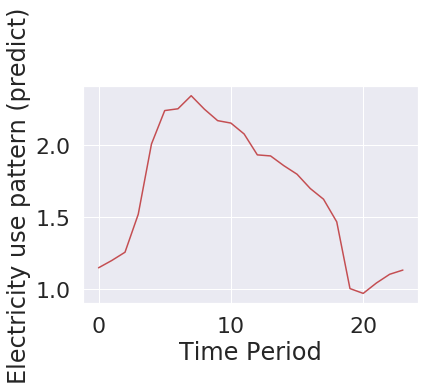

In [94]:
plt.figure()
plt.plot(time_electric_predict, 'r')
plt.xlabel('Time Period')
plt.ylabel('Electricity use pattern (predict)')
plt.show()